In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
def smooth(data, window_length):
    data_len = len(data)
    if window_length % 2 == 1:
        window_length += 1
    half_window = window_length // 2
    new_data = np.zeros(data_len)
    
    for i in range(data_len):
        window_sum = 0.0
        window_count = 0
        for j in range(i - half_window, i + half_window + 1):
            if j >= 0 and j < data_len:
                window_sum += data[j]
                window_count += 1
        new_data[i] = window_sum / window_count
    return new_data

(234,)
117
(7167,)


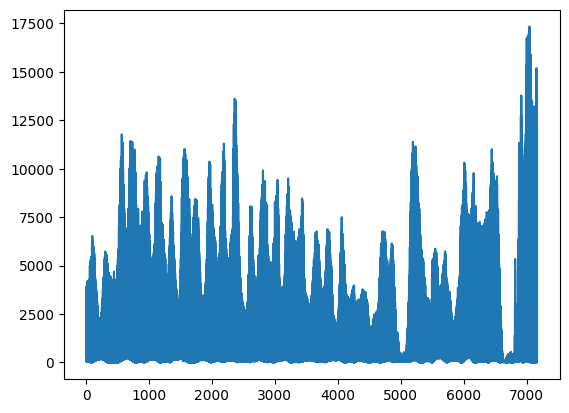

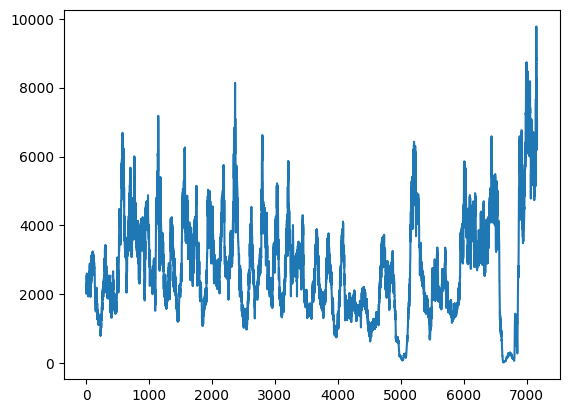

[[5.0810e+03 3.7000e+01 5.0000e+01 ... 2.5000e+01 1.5170e+04 3.4000e+01]
 [3.8330e+03 5.3000e+01 5.0000e+01 ... 1.6000e+01 1.2330e+04 4.1000e+01]
 [4.5050e+03 3.7000e+01 3.6000e+01 ... 1.6000e+01 1.6193e+04 2.5000e+01]
 ...
 [4.4690e+03 4.1000e+01 2.6000e+01 ... 1.4500e+02 1.1848e+04 9.7000e+01]
 [4.8850e+03 4.1000e+01 2.6000e+01 ... 1.2800e+02 5.3370e+03 9.0000e+01]
 [5.4500e+03 3.4000e+01 4.0000e+01 ... 1.3000e+02 4.2890e+03 1.2500e+02]]
[[2489.25       2959.8        2475.33333333 ... 8158.66666667
  6751.8        8436.5       ]
 [1936.25       2246.         1877.83333333 ... 6298.16666667
  4996.8        6241.75      ]
 [2501.         2697.8        2254.83333333 ... 8094.33333333
  6484.2        8099.        ]
 ...
 [2776.5        3071.2        2565.         ... 4213.5
  3006.2        3711.5       ]
 [2311.         2862.         2393.66666667 ... 2208.66666667
  1942.8        2391.25      ]
 [2575.25       3165.2        2645.16666667 ... 3457.16666667
  3082.6        3812.25      ]]

In [165]:
evaluation_set = pd.read_csv("evaluation/CSI20250227_193124.csv")

evaluation_set = evaluation_set['data'].apply(lambda x: np.array(eval(x))).to_numpy()
print(evaluation_set[0].shape)
# evaluation_set = evaluation_set[2000: 3000]

T = evaluation_set.shape[0]

num_subcarriers = evaluation_set[0].shape[0] // 2
print(num_subcarriers)

csi_matrix = np.zeros((num_subcarriers, T))

print(evaluation_set.shape)

sizes = {}

# for t in range(T):
#     if evaluation_set[t].shape not in sizes:
#         sizes[evaluation_set[t].shape] = 1
#     else:
#         sizes[evaluation_set[t].shape] += 1
#     # print(evaluation_set[t].shape)
# print(sizes)
for t in range(T):
    for sc in range(num_subcarriers):
        # print(evaluation_set[t].shape, t)
        if sc * 2 + 1 < evaluation_set[t].shape[0]:
            csi_matrix[sc][t] = evaluation_set[t][sc * 2] ** 2 + evaluation_set[t][sc * 2 + 1] ** 2


plt.plot(csi_matrix[1])
plt.show()
smoothed_csi = smooth(csi_matrix[1], 12)

plt.plot(smoothed_csi)
plt.show()

print(csi_matrix)

for sc in range(num_subcarriers):
    csi_matrix[sc] = smooth(csi_matrix[sc], 6)

print(csi_matrix)


# acf_across_subcarrier = np.zeros((num_subcarriers, T))

# for sc in range(num_subcarriers):
#     for lag in range(T):
#         acf_across_subcarrier[sc][lag] = acf_lag(csi_matrix[sc], lag)

In [166]:
csi_matrix_transpose = np.transpose(csi_matrix)
csi_matrix_transpose = csi_matrix_transpose.astype(np.int64)
print(csi_matrix_transpose)

with open("test_data_downsampled.txt", 'w') as f:
    cnt = 0
    for t_instance in csi_matrix_transpose:
        if cnt % 4 == 0:
            f.write(str(np.ndarray.tolist(t_instance)).strip(']').strip('[') + '\n')
        cnt += 1

[[2489 1936 2501 ... 2776 2311 2575]
 [2959 2246 2697 ... 3071 2862 3165]
 [2475 1877 2254 ... 2565 2393 2645]
 ...
 [8158 6298 8094 ... 4213 2208 3457]
 [6751 4996 6484 ... 3006 1942 3082]
 [8436 6241 8099 ... 3711 2391 3812]]


In [176]:
def align_and_plot_mae(arr1, arr2, filename, label1, label2):
    if len(arr1) >= len(arr2):
        long_arr = arr1
        short_arr = arr2
    else:
        long_arr = arr2
        short_arr = arr1

    m = len(short_arr)
    n = len(long_arr)
    max_shift = n - m

    if max_shift < 0:
        raise ValueError("The longer array must be at least as long as the shorter array.")
    best_shift = 0
    min_mae = float('inf')
    for shift in range(max_shift + 1):
        window = long_arr[shift : shift + m]
        current_mae = np.mean(np.abs(window - short_arr))
        if current_mae < min_mae:
            min_mae = current_mae
            best_shift = shift
    aligned_long = long_arr[best_shift : best_shift + m]
    aligned_short = short_arr

    if len(arr1) >= len(arr2):
        label_long = label1 + " (truncated)"
        label_short = label2
    else:
        label_long = label2 + " (truncated)"
        label_short = label1
    x = np.arange(m)
    plt.clf()
    plt.figure(figsize=(10, 5))
    plt.scatter(x, aligned_long, label=label_long, alpha=0.5, color='blue', s=50)
    plt.scatter(x, aligned_short, label=label_short, alpha=0.5, color='red', s=50)
    plt.xlabel('Time horizon (sec)', fontsize=20)
    plt.ylabel('Breath Per Minute (BPM)', fontsize=20)
    plt.title(f'optimal alignment (shift={best_shift}); MAE={min_mae:.3f}', fontsize=18)
    plt.xticks(x, (x * 25 / 15).round(decimals=1), rotation = 45, fontsize=6.5)
    plt.legend(loc="lower left", fontsize=18)
    plt.ylim(8, max(np.max(aligned_long), np.max(aligned_short)) + 2)
    plt.xlim(-1, np.max(x) + 1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=1500)

<Figure size 640x480 with 0 Axes>

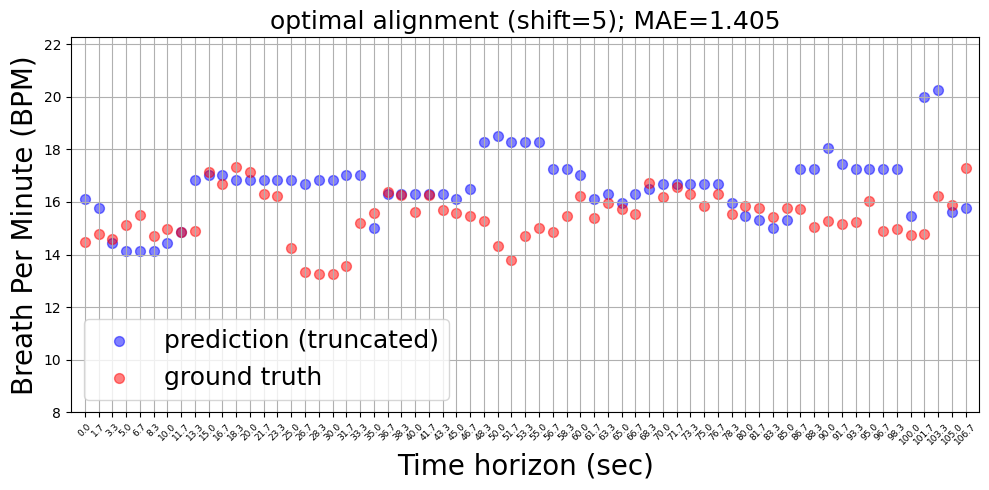

In [ ]:
prediction_path = "bpms.txt"
prediction = []
with open(prediction_path, 'r') as f:
    for line in f:
        prediction.append(float(line.strip()))

file_idx = "20250227_191018"

gt_path = "evaluation/gt_" + file_idx + ".csv"
ground_truth = pd.read_csv(gt_path)
ground_truth = ground_truth['bpm'].to_list()

# prediction = smooth(prediction, 2)

prediction = np.array(prediction)
ground_truth = np.array(ground_truth)

align_and_plot_mae(prediction, ground_truth, "BPM_" + file_idx + ".pdf", "prediction", "ground truth")